## Workflow :
1) Indexer les données (DataFrames : chemins + labels)
2) Transformer les Images (redimensionnement/normalisation/augmentation)
3) Charger par lots (Dataset + DataLoader)
4) Définir le modèle (CNN)
5) Entraîner (forward,loss,backward,update)
6) Valider (métriques sur la validation)
7) sauvegarder le meilleur checkpoint

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple
import torch
import pandas as pd
from PIL import Image
import numpy as np
import random
import os
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
"""
# cuda install
import sys
print(sys.executable)  # confirms which Python this notebook is using
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
"""

'\n# cuda install\nimport sys\nprint(sys.executable)  # confirms which Python this notebook is using\n!{sys.executable} -m pip install --upgrade pip\n!{sys.executable} -m pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129\nprint("torch:", torch.__version__)\nprint("torch cuda:", torch.version.cuda)\nprint("cuda available:", torch.cuda.is_available())\nif torch.cuda.is_available():\n    print("gpu:", torch.cuda.get_device_name(0))\n'

In [3]:

print(sys.executable)
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

C:\Users\thaim\Documents\mini-projects\2025-2026\mlprojects\pneumoniaCnnClassification\venv\Scripts\python.exe
torch: 2.8.0+cu129
torch cuda: 12.9
cuda available: True
device_count: 1
gpu: NVIDIA GeForce RTX 4070 Laptop GPU


In [4]:
# Vérifier root
print("Current working directory:\n", Path.cwd(),"\n")

Current working directory:
 C:\Users\thaim\Documents\mini-projects\2025-2026\mlprojects\pneumoniacnnclassification\notebooks 



In [5]:
# Resolve project root without changing the working directory
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name.lower() == "notebooks" else cwd
print("Current working directory:", cwd)
print("Project root:", project_root)


Current working directory: C:\Users\thaim\Documents\mini-projects\2025-2026\MLProjects\pneumoniaCnnClassification\notebooks
Project root: C:\Users\thaim\Documents\mini-projects\2025-2026\MLProjects\pneumoniaCnnClassification


In [6]:
# Charger les DataFrames generes pendant l'EDA
eda_dir = project_root / "eda_outputs"
if not eda_dir.exists():
    raise FileNotFoundError(f"Missing folder: {eda_dir}")

trainDf = pd.read_csv(eda_dir / "train.csv")
valDf = pd.read_csv(eda_dir / "val.csv")
testDf = pd.read_csv(eda_dir / "test.csv")


In [7]:
print("Size : ", len(trainDf))
trainDf.head()

Size :  5216


,path,label,class_name,split
0,data\chest_xray\train\PNEUMONIA\person1288_vir...,1,PNEUMONIA,train
1,data\chest_xray\train\NORMAL\NORMAL2-IM-0816-0...,0,NORMAL,train
2,data\chest_xray\train\PNEUMONIA\person61_bacte...,1,PNEUMONIA,train
3,data\chest_xray\train\PNEUMONIA\person722_viru...,1,PNEUMONIA,train
4,data\chest_xray\train\PNEUMONIA\person1141_vir...,1,PNEUMONIA,train


In [8]:
print("Size : ", len(valDf))
valDf.head()

Size :  16


,path,label,class_name,split
0,data\chest_xray\val\NORMAL\NORMAL2-IM-1427-000...,0,NORMAL,val
1,data\chest_xray\val\NORMAL\NORMAL2-IM-1430-000...,0,NORMAL,val
2,data\chest_xray\val\NORMAL\NORMAL2-IM-1438-000...,0,NORMAL,val
3,data\chest_xray\val\PNEUMONIA\person1952_bacte...,1,PNEUMONIA,val
4,data\chest_xray\val\PNEUMONIA\person1951_bacte...,1,PNEUMONIA,val


In [9]:
print("Size : ", len(testDf))
testDf.head()

Size :  624


,path,label,class_name,split
0,data\chest_xray\test\PNEUMONIA\person1655_viru...,1,PNEUMONIA,test
1,data\chest_xray\test\PNEUMONIA\person21_virus_...,1,PNEUMONIA,test
2,data\chest_xray\test\NORMAL\NORMAL2-IM-0357-00...,0,NORMAL,test
3,data\chest_xray\test\NORMAL\NORMAL2-IM-0352-00...,0,NORMAL,test
4,data\chest_xray\test\PNEUMONIA\person173_bacte...,1,PNEUMONIA,test


## Prétraitement
#### *Transformer les Images (redimensionnement/normalisation/augmentation)*

In [10]:
# IMAGENET Statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [11]:
def make_transforms(img_size: int = 224, augment: bool = True, use_imagenet_norm: bool = True):
    mean = IMAGENET_MEAN if use_imagenet_norm else [0.5, 0.5, 0.5]
    std  = IMAGENET_STD  if use_imagenet_norm else [0.5, 0.5, 0.5]
    """
    trains_ops : liste d’opérations pour les images d’entraînement
    eval_ops : liste d’opérations pour les images d’évaluation

    Liste actuelle des opérations :
    1) redimensionnement à une taille fixe
    2) centraliser l'image
    3) aplliquer des transformations aléatoires si True pour train
    4) convertir en tensor
    5) normaliser l'intensité en appliquant z-score
    """
    # base operations
    base = [
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
    ]
    train_ops = base.copy()
    # augment -> appliquer des transformations aléatoires si True
    if augment:
        train_ops += [
            transforms.RandomRotation(5),
        ]
    train_ops += [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
    eval_ops = base + [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
    base = base + [
        transforms.ToTensor(),
    ]
    return transforms.Compose(base), transforms.Compose(train_ops), transforms.Compose(eval_ops)

In [12]:
baseTransform, trainTransform, valTransform = make_transforms()

In [13]:
baseTransform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
)

In [14]:
trainTransform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [15]:
valTransform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

#### *Charger par lots (Dataset + DataLoader)*

In [16]:
# config
@dataclass(frozen=True)
class LoaderConfig:
    batch_size: int = 32
    num_workers: int = 0
    pin_memory: bool = True
    seed: int = 42

In [17]:
# dataset class
def resolve_image_path(path_value, base_dir=None) -> Path:
    p = Path(str(path_value))
    candidates = []

    if p.is_absolute():
        candidates.append(p)
    else:
        if base_dir is not None:
            candidates.append(Path(base_dir) / p)
        if "project_root" in globals():
            candidates.append(Path(project_root) / p)
        candidates.append(Path.cwd() / p)
        candidates.append(p)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    tried = " | ".join(str(c) for c in candidates)
    raise FileNotFoundError(f"Image file not found: {path_value}. Tried: {tried}")


class XRayDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None, base_dir=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.base_dir = Path(base_dir) if base_dir is not None else None

    # pytorch require getting length
    def __len__(self):
        return len(self.df)

    # pytorch require getting sample
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(row["path"], self.base_dir)
        img = Image.open(img_path).convert("RGB")
        y = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor([y], dtype=torch.float32)


In [18]:
loaderCfg = LoaderConfig()

random.seed(loaderCfg.seed)
np.random.seed(loaderCfg.seed)
torch.manual_seed(loaderCfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(loaderCfg.seed)

loaderGenerator = torch.Generator()
loaderGenerator.manual_seed(loaderCfg.seed)

trainLoader = DataLoader(
    XRayDataset(df=trainDf, transform=trainTransform, base_dir=project_root),
    batch_size=loaderCfg.batch_size,
    shuffle=True,
    num_workers=loaderCfg.num_workers,
    pin_memory=loaderCfg.pin_memory,
    generator=loaderGenerator,
)
valLoader = DataLoader(
    XRayDataset(df=valDf, transform=valTransform, base_dir=project_root),
    batch_size=loaderCfg.batch_size,
    shuffle=False,
    num_workers=loaderCfg.num_workers,
    pin_memory=loaderCfg.pin_memory,
    generator=loaderGenerator,
)
testLoader = DataLoader(
    XRayDataset(df=testDf, transform=valTransform, base_dir=project_root),
    batch_size=loaderCfg.batch_size,
    shuffle=False,
    num_workers=loaderCfg.num_workers,
    pin_memory=loaderCfg.pin_memory,
    generator=loaderGenerator,
)


In [19]:
trainLoader,valLoader,testLoader

(<torch.utils.data.dataloader.DataLoader at 0x1b28fc39810>,
 <torch.utils.data.dataloader.DataLoader at 0x1b28fc388b0>)

#### Inspection visuelle

In [20]:
def visual_inspect(
    trainDf: pd.DataFrame,
    base_transform,
    normalized_transform=None,
    n: int = 5,
    seed: int = 42,
    random_sample: bool = True,
    save: bool = False,
    base_dir=None
):
    n = min(n, len(trainDf))
    sample = (trainDf.sample(n=n, random_state=seed) if random_sample else trainDf.iloc[:n]).reset_index(drop=True)

    if normalized_transform is None:
        if isinstance(base_transform, transforms.Compose):
            normalized_transform = transforms.Compose(list(base_transform.transforms) + [
                transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
            ])
        else:
            raise ValueError("Provide normalized_transform, or pass base_transform as torchvision.transforms.Compose")

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    fig, axes = plt.subplots(3, n, figsize=(3*n, 9))
    if n == 1:
        axes = axes.reshape(3, 1)

    for j, row in sample.iterrows():
        # --- Raw ---
        img_path = resolve_image_path(row["path"], base_dir=base_dir)
        img_pil = Image.open(img_path).convert("RGB")
        axes[0, j].imshow(img_pil)
        axes[0, j].set_title(f"Raw | y={int(row['label'])}")
        axes[0, j].axis("off")

        # --- Preprocessed WITHOUT norm ---
        x_no = base_transform(img_pil)  # tensor [3,H,W] in [0,1]
        axes[1, j].imshow(x_no.permute(1, 2, 0).clamp(0, 1))
        axes[1, j].set_title("Preproc (no norm)")
        axes[1, j].axis("off")

        # --- Preprocessed WITH norm (unnormalized for display) ---
        x_norm = normalized_transform(img_pil)  # normalized tensor
        x_vis = (x_norm * std) + mean
        axes[2, j].imshow(x_vis.permute(1, 2, 0).clamp(0, 1))
        axes[2, j].set_title("Preproc (with norm)")
        axes[2, j].axis("off")

    plt.tight_layout()
    if save:
        plt.savefig("preprocessedInspectSample.png", bbox_inches="tight")
    plt.show()


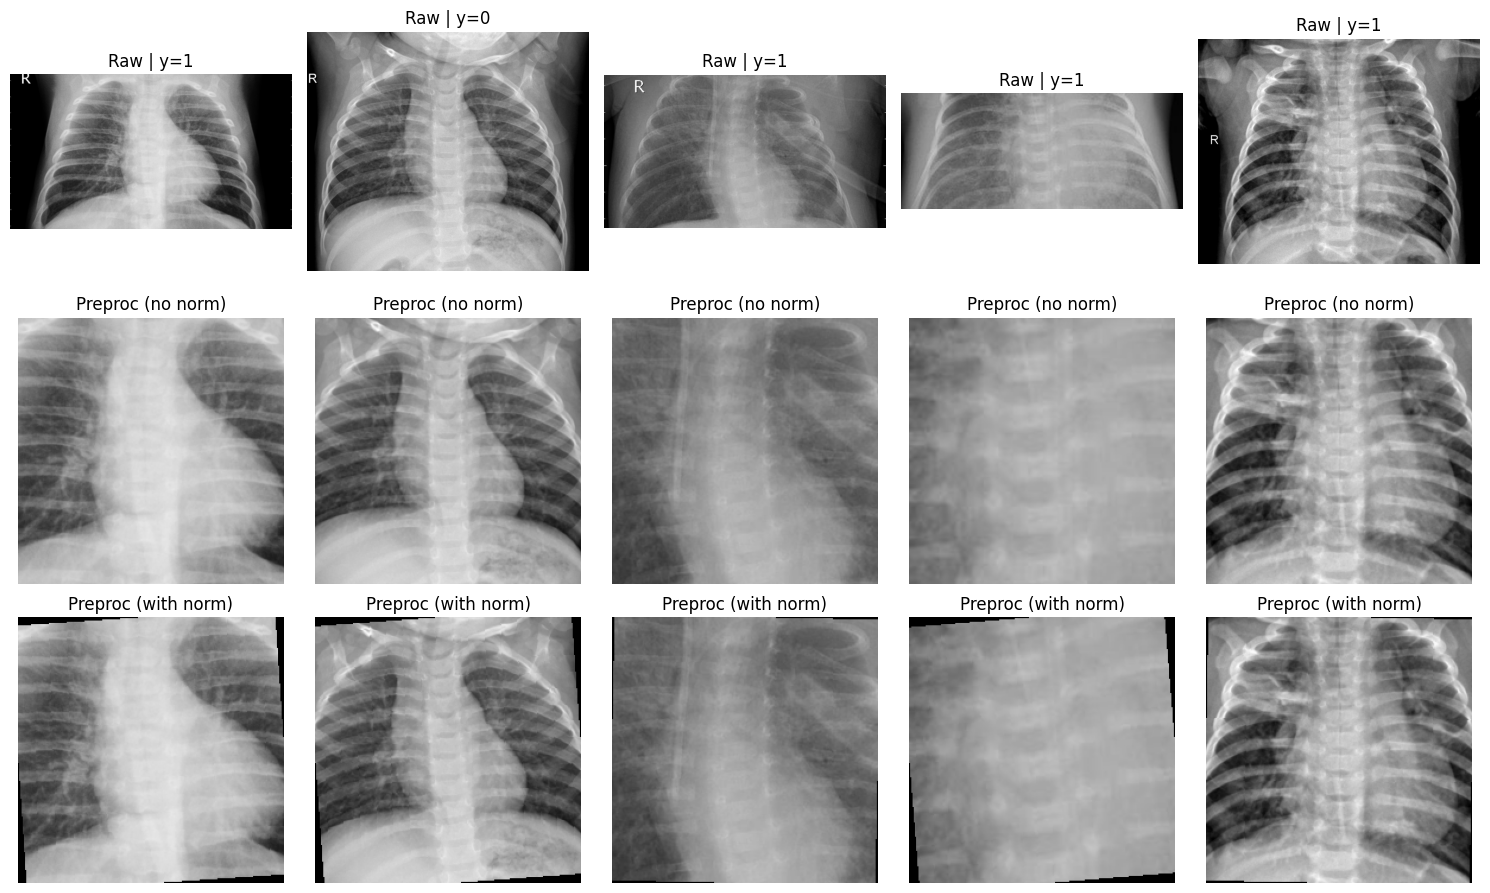

In [21]:
visual_inspect(trainDf, baseTransform, trainTransform, n=5, save=True, base_dir=project_root)


#### *Définir le modèle (Baseline CNN)*

In [22]:
class BaselineCNN(nn.Module):
    def __init__(self, in_channels: int = 3, dropout_p: float = 0.5, input_size: int = 224):
        super().__init__()
        self.features = nn.Sequential(
            # couche 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # couche 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # couche 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        # flatten
        h = input_size // 8
        w = input_size // 8
        flatten_dim = 128 * h * w
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


#### Entrainement

In [23]:
@dataclass(frozen=True)
class TrainConfig:
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 0.0
    early_stopping_patience: int = 6
    min_delta: float = 1e-4
    use_class_weights: bool = True
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


In [28]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    logits = logits.view(-1)
    y = y.view(-1)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    return (preds == y).float().mean().item()

In [29]:
def train_one_epoch(model, loader, loss_fn, optimizer, device: str) -> Tuple[float, float]:
    model.train()
    losses, accs = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).view(-1, 1)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits.detach(), y))
    return float(np.mean(losses)), float(np.mean(accs))

In [30]:
@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, device: str) -> Tuple[float, float, float]:
    from sklearn.metrics import roc_auc_score

    model.eval()
    losses, accs = [], []
    all_probs, all_targets = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).view(-1, 1)

        logits = model(x)
        loss = loss_fn(logits, y)

        probs = torch.sigmoid(logits)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))
        all_probs.append(probs.detach().cpu())
        all_targets.append(y.detach().cpu())

    probs = torch.cat(all_probs).view(-1).numpy()
    y_true = torch.cat(all_targets).view(-1).numpy().astype(int)
    if len(np.unique(y_true)) > 1:
        val_auc = float(roc_auc_score(y_true, probs))
    else:
        val_auc = float("nan")

    return float(np.mean(losses)), float(np.mean(accs)), val_auc


In [34]:
def fit(model, loaders: Dict[str, torch.utils.data.DataLoader], cfg: TrainConfig):
    device = cfg.device
    model.to(device)

    pos_weight = None
    if cfg.use_class_weights:
        train_dataset = loaders["train"].dataset
        if hasattr(train_dataset, "df") and "label" in train_dataset.df.columns:
            y_train = train_dataset.df["label"].astype(int).to_numpy()
            n_pos = int((y_train == 1).sum())
            n_neg = int((y_train == 0).sum())
            if n_pos > 0 and n_neg > 0:
                pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

    if pos_weight is None:
        loss_fn = nn.BCEWithLogitsLoss()
        print("Using BCEWithLogitsLoss without class weighting")
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"Using BCEWithLogitsLoss with pos_weight={pos_weight.item():.4f}")
        
    # optimize adam
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": [],
    }

    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    stopped_early = False
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, loaders["train"], loss_fn, optimizer, device)
        va_loss, va_acc, va_auc = validate_one_epoch(model, loaders["val"], loss_fn, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["val_auc"].append(va_auc)

        improved = va_loss < (best_val_loss - cfg.min_delta)
        if improved:
            best_val_loss = va_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{cfg.epochs} | "
            f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
            f"val_loss={va_loss:.4f} acc={va_acc:.4f} auc={va_auc:.4f}"
        )
        # Early stopping
        if cfg.early_stopping_patience > 0 and epochs_without_improvement >= cfg.early_stopping_patience:
            stopped_early = True
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best epoch was {best_epoch} with val_loss={best_val_loss:.4f}"
            )
            break

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val_loss
    history["stopped_early"] = stopped_early
    return history


In [31]:
# Train (fit)
cfg = TrainConfig(
    epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    early_stopping_patience=6,
    min_delta=1e-4,
    use_class_weights=True,
)
model = BaselineCNN(input_size=224)
loaders = {"train": trainLoader, "val": valLoader}
history = fit(model, loaders, cfg)
print({
    "best_epoch": history["best_epoch"],
    "best_val_loss": history["best_val_loss"],
    "stopped_early": history["stopped_early"],
})


Epoch 01/20 | train_loss=0.2303 acc=0.9095 | val_loss=1.1855 acc=0.7500
Epoch 02/20 | train_loss=0.1572 acc=0.9450 | val_loss=0.6896 acc=0.7500
Epoch 03/20 | train_loss=0.1157 acc=0.9574 | val_loss=0.6992 acc=0.6875
Epoch 04/20 | train_loss=0.1057 acc=0.9603 | val_loss=1.1032 acc=0.5625
Epoch 05/20 | train_loss=0.0962 acc=0.9682 | val_loss=0.8268 acc=0.8125
Epoch 06/20 | train_loss=0.0895 acc=0.9655 | val_loss=0.7926 acc=0.6250
Epoch 07/20 | train_loss=0.0811 acc=0.9701 | val_loss=0.5516 acc=0.6875
Epoch 08/20 | train_loss=0.0767 acc=0.9711 | val_loss=0.5223 acc=0.7500
Epoch 09/20 | train_loss=0.0728 acc=0.9722 | val_loss=0.6696 acc=0.6875
Epoch 10/20 | train_loss=0.0695 acc=0.9734 | val_loss=1.0366 acc=0.6250
Epoch 11/20 | train_loss=0.0635 acc=0.9768 | val_loss=0.7383 acc=0.6875
Epoch 12/20 | train_loss=0.0633 acc=0.9739 | val_loss=0.4038 acc=0.7500
Epoch 13/20 | train_loss=0.0640 acc=0.9747 | val_loss=0.5207 acc=0.6875
Epoch 14/20 | train_loss=0.0633 acc=0.9747 | val_loss=0.5249 acc

#### Plot training curve

In [36]:
def plot_training_curves(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    has_auc = "val_auc" in history and len(history["val_auc"]) == len(epochs)

    ncols = 3 if has_auc else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))

    if ncols == 1:
        axes = [axes]

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Optional AUC
    if has_auc:
        axes[2].plot(epochs, history["val_auc"], label="Val AUC", color="purple")
        axes[2].set_title("Validation AUC")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("AUC")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

    plt.tight_layout()
    plt.show()

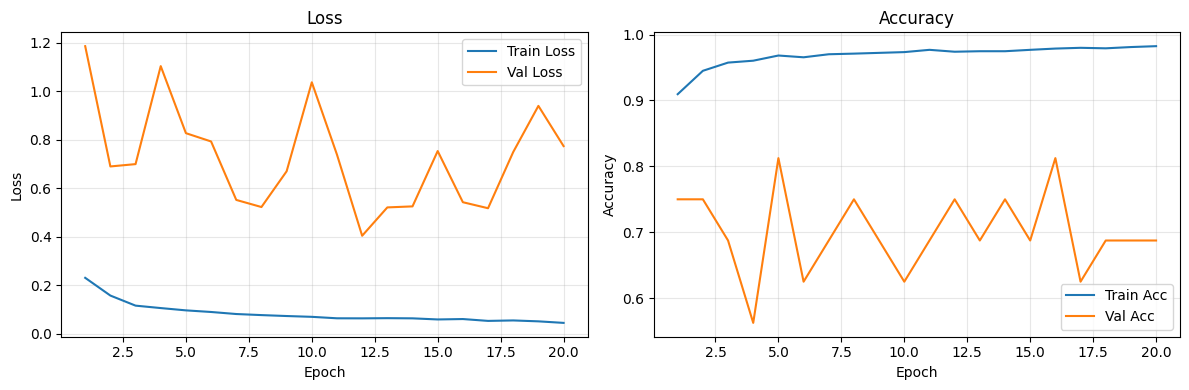

In [37]:
plot_training_curves(history)

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

@torch.no_grad()
def evaluate_on_test(model, loader, device: str, threshold: float = 0.5):
    model.eval()
    model.to(device)
    loss_fn = nn.BCEWithLogitsLoss()

    losses = []
    all_probs = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).view(-1, 1)

        logits = model(x)
        loss = loss_fn(logits, y)

        probs = torch.sigmoid(logits)
        losses.append(loss.item())
        all_probs.append(probs.cpu())
        all_targets.append(y.cpu())

    probs = torch.cat(all_probs).view(-1).numpy()
    y_true = torch.cat(all_targets).view(-1).numpy().astype(int)
    y_pred = (probs >= threshold).astype(int)

    metrics = {
        "test_loss": float(np.mean(losses)),
        "test_acc": float((y_pred == y_true).mean()),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    if len(np.unique(y_true)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y_true, probs))
    else:
        metrics["roc_auc"] = float("nan")

    return metrics


In [33]:
# Evaluate on test and save checkpoint
test_metrics = evaluate_on_test(model, testLoader, device=cfg.device)
print(test_metrics)

ckpt_path = project_root / "baseline_cnn_last.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": cfg.__dict__,
        "history": history,
        "test_metrics": test_metrics,
    },
    ckpt_path,
)
print(f"Saved checkpoint: {ckpt_path}")


{'test_loss': 1.5617159754037857, 'test_acc': 0.7644230769230769, 'precision': 0.7314285714285714, 'recall': 0.9846153846153847, 'f1': 0.839344262295082, 'roc_auc': 0.8576210826210826}
Saved checkpoint: C:\Users\thaim\Documents\mini-projects\2025-2026\MLProjects\pneumoniaCnnClassification\baseline_cnn_last.pt


## Conclusion finale (modèle CNN binaire Pneumonie vs Normal)

### 1) Métriques finales sur le jeu de test
Sur **624 images de test**, le modèle obtient :
- **Accuracy** : **0.7644** (76.44 %)
- **Precision** : **0.7314**
- **Recall (sensibilité)** : **0.9846**
- **F1-score** : **0.8393**
- **AUC-ROC** : **0.8576**

Ces résultats montrent un modèle très sensible à la classe *PNEUMONIA*, avec une bonne capacité globale de séparation (AUC > 0.85).

### 2) Analyse de la matrice de confusion
Matrice de confusion (classe positive = Pneumonia) :
- **TP = 384**
- **TN = 93**
- **FP = 141**
- **FN = 6**

| Réel \\ Prédit | Normal (0) | Pneumonia (1) |
|---|---:|---:|
| Normal (0) | 93 | 141 |
| Pneumonia (1) | 6 | 384 |

Interprétation :
- Très peu de **FN** (cas de pneumonie manqués).
- Beaucoup de **FP** (normaux classés à tort comme pneumonie).

### 3) Discussion FN vs FP (impact clinique)
- **FN (6)** : cliniquement les plus critiques, car ils peuvent retarder un diagnostic et une prise en charge.
- **FP (141)** : moins dangereux médicalement, mais augmentent les examens complémentaires inutiles, le stress patient et la charge clinique.
- Le modèle actuel privilégie clairement la **sensibilité** (rappel élevé), ce qui est pertinent pour un usage de **dépistage**, mais pas suffisant seul pour une décision diagnostique finale.

### 4) Courbes entraînement vs validation (overfitting/underfitting)
Observation du run :
- `train_loss` diminue fortement (**0.2303 -> 0.0446**), `train_acc` monte jusqu’à **0.9824**.
- `val_loss` est instable (minimum vers **epoch 12 : 0.4038**, puis remontée), `val_acc` fluctue (environ **0.56 à 0.81**).
- Conclusion : **surapprentissage (overfitting)** après les meilleures époques de validation.

### 5) Capacité de généralisation
- Généralisation **correcte mais imparfaite** : accuracy test modérée (76 %) avec AUC solide.
- Le modèle généralise bien pour détecter les pneumonies (rappel élevé), mais moins bien pour reconnaître la classe normale (spécificité faible à cause des FP).

### 6) Exemples de prédictions (correctes et incorrectes)
Exemples corrects (TP) :
- `test/PNEUMONIA/person143_bacteria_688.jpeg` (prédit Pneumonia, confiance ~1.00)
- `test/PNEUMONIA/person51_virus_105.jpeg` (prédit Pneumonia, confiance ~1.00)

Exemples incorrects (FP) :
- `test/NORMAL/NORMAL2-IM-0256-0001.jpeg` (prédit Pneumonia, confiance ~1.00)
- `test/NORMAL/IM-0073-0001.jpeg` (prédit Pneumonia, confiance ~1.00)

### 7) Analyse d’erreurs
Causes probables des erreurs :
- Déséquilibre de classes et/ou seuil de décision fixe (0.5) non optimal.
- Variabilité forte des radios normales pouvant ressembler à des patterns pathologiques.
- Modèle CNN de base (capacité limitée) et possible sensibilité à des artefacts (contraste, cadrage, annotations).

### 8) Vérification d’interprétabilité (Grad-CAM)
Contrôle recommandé :
- Vérifier que les heatmaps se concentrent sur les **zones pulmonaires pertinentes**.
- Comparer Grad-CAM entre TP, FP et FN.
- Si l’activation se fait sur les bords, textes, marqueurs ou zones hors poumons, cela indique des corrélations non cliniques.

### 9) Limites du dataset et du modèle
- Dataset possiblement petit et non représentatif de toute la diversité clinique.
- Risque de biais de source (hôpital, machine, protocole d’acquisition).
- Baseline CNN simple sans mécanismes avancés de robustesse/calibration.
- Absence de calibration explicite des probabilités.

### 10) Pistes d’amélioration
1. Renforcer l’augmentation de données (intensité, géométrie, contraste) de manière réaliste médicalement.
2. Utiliser du **transfer learning** (ResNet/EfficientNet/DenseNet pré-entraînés).
3. Optimiser les hyperparamètres (LR scheduler, batch size, dropout, weight decay).
4. Ajuster le **seuil de décision** selon l’objectif clinique (sensibilité vs spécificité).
5. Ajouter validation croisée et calibration (Platt/temperature scaling).
6. Ajouter early stopping robuste + suivi systématique AUC/PR-AUC en validation.


In [40]:
from torchvision.transforms.functional import to_pil_image

def export_preprocessed_from_loader_dataset(loader, out_dir, save_tensor=True):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    ds = loader.dataset
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for i in range(len(ds)):
        x, y = ds[i]  # x is already preprocessed by valTransform
        rel = Path(ds.df.iloc[i]["path"]).with_suffix(".png")  # keep subfolders
        png_path = out_dir / rel
        png_path.parent.mkdir(parents=True, exist_ok=True)

        # For viewable PNG: undo normalization
        x_vis = (x * std + mean).clamp(0, 1)
        to_pil_image(x_vis).save(png_path)

        # Optional: save exact model input tensor (normalized)
        if save_tensor:
            torch.save(
                {"x": x, "y": int(y.item())},
                png_path.with_suffix(".pt")
            )

    print(f"Saved preprocessed files to: {out_dir}")

# Example
#export_preprocessed_from_loader_dataset(valLoader, project_root / "training_outputs" / "val_preprocessed")
"""
.png = human-viewable image (unnormalized for display).
.pt = exact normalized tensor used by the model.
"""

'\n.png = human-viewable image (unnormalized for display).\n.pt = exact normalized tensor used by the model.\n'